# Assignment 1 - Step 3 Nodal

In [1]:
#Import relevant libraries
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import os
hour = int(os.environ['HOUR'])

In [2]:
DATA_DIR = os.path.join(os.environ['PYTHONPATH'], 'data_from_Jakob')

W1_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone1.csv'))
W1_CF   = W1_data.iloc[1:25, 1:].mean(axis=1)

W2_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone2.csv'))
W2_CF   = W2_data.iloc[1:25, 1:].mean(axis=1)

W3_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone3.csv'))
W3_CF   = W3_data.iloc[1:25, 1:].mean(axis=1)

W4_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone4.csv'))
W4_CF   = W4_data.iloc[1:25, 1:].mean(axis=1)

W5_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone5.csv'))
W5_CF   = W5_data.iloc[1:25, 1:].mean(axis=1)

W6_data = pd.read_csv(os.path.join(DATA_DIR, 'scen_zone6.csv'))
W6_CF   = W6_data.iloc[1:25, 1:].mean(axis=1)

In [3]:
from data import load_distribution, load_profile, generators, generator_bid_prices
from data import Prices_for_loads, transmission_lines

#create variable list with the names of the variables as strings
VARIABLES = list(generators.keys())

LOAD_VARIABLES = list(load_distribution.keys())

VOLTAGE_ANGLES = [f"theta_{i}" for i in range(1, 25)]

#create a list of the cost coefficients for each variable
Generation_price = [v[hour] for v in generator_bid_prices.values()]

#writes a list that converts the cost coefficient to this form objective_coeff = {'G1': 13.32, 'G2': 13.32, ...}
objective_coeff = {VARIABLES[i]: Generation_price[i] for i in range(len(VARIABLES))}



#write the load percentages for each node
Load_percentage = [v['percent'] for v in load_distribution.values()]
#multiply the load percentage with the total load to get the actual load in MW
hour12_load = load_profile[hour] #MW

#Load upper bound list for each load variable
Load = [hour12_load * (i / 100) for i in Load_percentage] #MW


#random price list with 17 values and sort it in descending order
#change prices for clarity in the plot
Randonm_prices_h1 = Prices_for_loads[hour]
Demand_price= np.array(sorted(Randonm_prices_h1, reverse=True)) #$/MWh 

#writes a list that converts the load coefficient to this form objective_coeff = {'Load1': 13.32, 'Load2': 13.32, ...}
Load_coefficients = {LOAD_VARIABLES[i]: Demand_price[i] for i in range(len(LOAD_VARIABLES))}

#create a upper bound for the production variables
Generator_UB = [v['Pmax_MW'] for k, v in generators.items() if k.startswith('G')]

#Generator_UB = [152,152,350,591,60,155,155,400,400,300,310,350] #MW
Wind_UB = np.array([W1_CF[hour], W2_CF[hour], W3_CF[hour], W4_CF[hour],W5_CF[hour],W6_CF[hour]])*200
Constraints_rhs = Generator_UB + Wind_UB.tolist()
#create constraints sense list with 18 values of GRB.LESS_EQUAL
constraints_sense = [GRB.LESS_EQUAL] * 18




In [4]:
#Create model
model = gp.Model("Copperplate_singlehour")

Set parameter Username


Set parameter LicenseID to value 2658987


Academic license - for non-commercial use only - expires 2026-04-29


In [5]:
#Add variables
variables = {v: model.addVar(lb=0, name=f'variable {v}') for v in VARIABLES}

#Add load variables
load_variables = {l: model.addVar(lb=0, name=f'variable {l}') for l in LOAD_VARIABLES}

#Add voltage angle variables
voltage_angle_variables = {n: model.addVar(lb=-GRB.INFINITY, name=f'variable {n}') for n in range(1,25)}

slack_constraint = model.addConstr(voltage_angle_variables[13] == 0, name='Slack_constraint')



In [6]:
# Set objective function and optimization direction of the Gurobi model
objective = gp.quicksum(Load_coefficients[v] * load_variables[v] for v in LOAD_VARIABLES) - gp.quicksum(objective_coeff[v] * variables[v] for v in VARIABLES)
model.setObjective(objective, GRB.MAXIMIZE)


In [7]:
# Add constraints to the Gurobi model

#Add balance constraint to the Gurobi model that ensures that the total load is equal to the total generation
Balance_constraints = {}
for n in range(1, 25):

    Balance_constraints[n] = model.addLConstr(

        # Load at node n
        gp.quicksum(
            load_variables[v]
            for v in load_variables
            if load_distribution[v]['node'] == n
        )

        # minus Generation at node n
        - gp.quicksum(
            variables[v]
            for v in variables
            if generators[v]['node'] == n
        )

        +gp.quicksum(
            (voltage_angle_variables[n] -
             voltage_angle_variables[
                 transmission_lines[v]['to']
                 if transmission_lines[v]['from'] == n
                 else transmission_lines[v]['from']
             ]) / transmission_lines[v]['reactance']

            for v in transmission_lines
            if transmission_lines[v]['from'] == n
            or transmission_lines[v]['to'] == n
        ),

        GRB.EQUAL,
        0,
        name=f"Balance_constraint_{n}"
    )

#Balance_constraint = [
 #   model.addLConstr(
  #      gp.quicksum(load_variables[v] for v in load_variables)-gp.quicksum(variables[v] for v in variables), GRB.EQUAL, 0,
   #     name=f"Balance_constraint" 
   # )
    
#]

#Add boundary constraints to the Gurobi model that ensures that the generation of each generator is less than or equal to its upper bound
Boundary_constraints = {}

for v, rhs in zip(VARIABLES, Constraints_rhs):
    Boundary_constraints[v] = model.addLConstr(
        variables[v],
        GRB.LESS_EQUAL,
        rhs
    )

Boundary_constraints2 = {}
for v, rhs in zip(LOAD_VARIABLES, Load):
    Boundary_constraints2[v] = model.addLConstr(
        load_variables[v],
        GRB.LESS_EQUAL,
        rhs
    )

Boundary_constraints_lines = {}  # store line capacity constraints

for v in transmission_lines:  # v = line key
    i = transmission_lines[v]['from']
    j = transmission_lines[v]['to']
    X = transmission_lines[v]['reactance']
    Pmax = transmission_lines[v]['capacity_MVA']

    # Upper bound
    Boundary_constraints_lines[f"{v}_upper"] = model.addLConstr(
        (voltage_angle_variables[i] - voltage_angle_variables[j]) / X,
        GRB.LESS_EQUAL,
        Pmax,
        name=f"Line_{v}_upper"
    )

    # Lower bound
    Boundary_constraints_lines[f"{v}_lower"] = model.addLConstr(
        (voltage_angle_variables[i] - voltage_angle_variables[j]) / X,
        GRB.GREATER_EQUAL,
        -Pmax,
        name=f"Line_{v}_lower"
    )

In [8]:
model.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))


CPU model: 12th Gen Intel(R) Core(TM) i7-1255U, instruction set [SSE2|AVX|AVX2]


Thread count: 10 physical cores, 12 logical processors, using up to 12 threads


Optimize a model with 128 rows, 59 columns and 299 nonzeros


Model fingerprint: 0xb5e31f8f


...

Iteration    Objective       Primal Inf.    Dual Inf.      Time


       0      handle free variables                          0s


      29    6.9635681e+04   0.000000e+00   0.000000e+00      0s


Solved in 29 iterations and 0.01 seconds (0.00 work units)


Optimal objective  6.963568068e+04


In [9]:
# check that balance is maintained at each node
for n in range(1, 25):
    generation = sum(variables[v].X for v in variables if generators[v]['node'] == n)
    load = sum(load_variables[v].X for v in load_variables if load_distribution[v]['node'] == n)
    
    # sum flows on all lines connected to this node
    transmission = sum(
        (voltage_angle_variables[n].X - 
         voltage_angle_variables[transmission_lines[v]['to']].X) / transmission_lines[v]['reactance']
        if transmission_lines[v]['from'] == n
        else
        (voltage_angle_variables[n].X - 
         voltage_angle_variables[transmission_lines[v]['from']].X) / transmission_lines[v]['reactance']
        for v in transmission_lines
        if transmission_lines[v]['from'] == n or transmission_lines[v]['to'] == n
    )
    
    net_balance = generation - load - transmission
    print(f"sum of balance at node {n}: {net_balance:.6f} MW (should be close to 0)")

sum of balance at node 1: -0.000000 MW (should be close to 0)
sum of balance at node 2: 0.000000 MW (should be close to 0)
sum of balance at node 3: 0.000000 MW (should be close to 0)
sum of balance at node 4: 0.000000 MW (should be close to 0)
sum of balance at node 5: 0.000000 MW (should be close to 0)
sum of balance at node 6: -0.000000 MW (should be close to 0)
sum of balance at node 7: -0.000000 MW (should be close to 0)
sum of balance at node 8: 0.000000 MW (should be close to 0)
sum of balance at node 9: 0.000000 MW (should be close to 0)
sum of balance at node 10: 0.000000 MW (should be close to 0)
sum of balance at node 11: -0.000000 MW (should be close to 0)
sum of balance at node 12: -0.000000 MW (should be close to 0)
sum of balance at node 13: 0.000000 MW (should be close to 0)
sum of balance at node 14: 0.000000 MW (should be close to 0)
sum of balance at node 15: -0.000000 MW (should be close to 0)
sum of balance at node 16: -0.000000 MW (should be close to 0)
sum of bal

In [10]:
# write all the market prices
if model.status == GRB.OPTIMAL:
    for n in range(1, 25):
        print(f"Market price at node {n}: {Balance_constraints[n].Pi:.2f} $/MWh")


Market price at node 1: 16.80 $/MWh
Market price at node 2: 16.92 $/MWh
Market price at node 3: 12.95 $/MWh
Market price at node 4: 17.29 $/MWh
Market price at node 5: 17.60 $/MWh
Market price at node 6: 18.07 $/MWh
Market price at node 7: 18.01 $/MWh
Market price at node 8: 18.01 $/MWh
Market price at node 9: 17.59 $/MWh
Market price at node 10: 18.43 $/MWh
Market price at node 11: 21.60 $/MWh
Market price at node 12: 16.67 $/MWh
Market price at node 13: 18.21 $/MWh
Market price at node 14: 28.21 $/MWh
Market price at node 15: 5.60 $/MWh
Market price at node 16: 4.85 $/MWh
Market price at node 17: 5.12 $/MWh
Market price at node 18: 5.24 $/MWh
Market price at node 19: 7.23 $/MWh
Market price at node 20: 9.28 $/MWh
Market price at node 21: 5.35 $/MWh
Market price at node 22: 5.26 $/MWh
Market price at node 23: 10.42 $/MWh
Market price at node 24: 8.44 $/MWh


In [11]:
prices = []

for n in range(1, 25):
    prices.append(round(Balance_constraints[n].Pi, 2))

print(prices)

[16.8, 16.92, 12.95, 17.29, 17.6, 18.07, 18.01, 18.01, 17.59, 18.43, 21.6, 16.67, 18.21, 28.21, 5.6, 4.85, 5.12, 5.24, 7.23, 9.28, 5.35, 5.26, 10.42, 8.44]


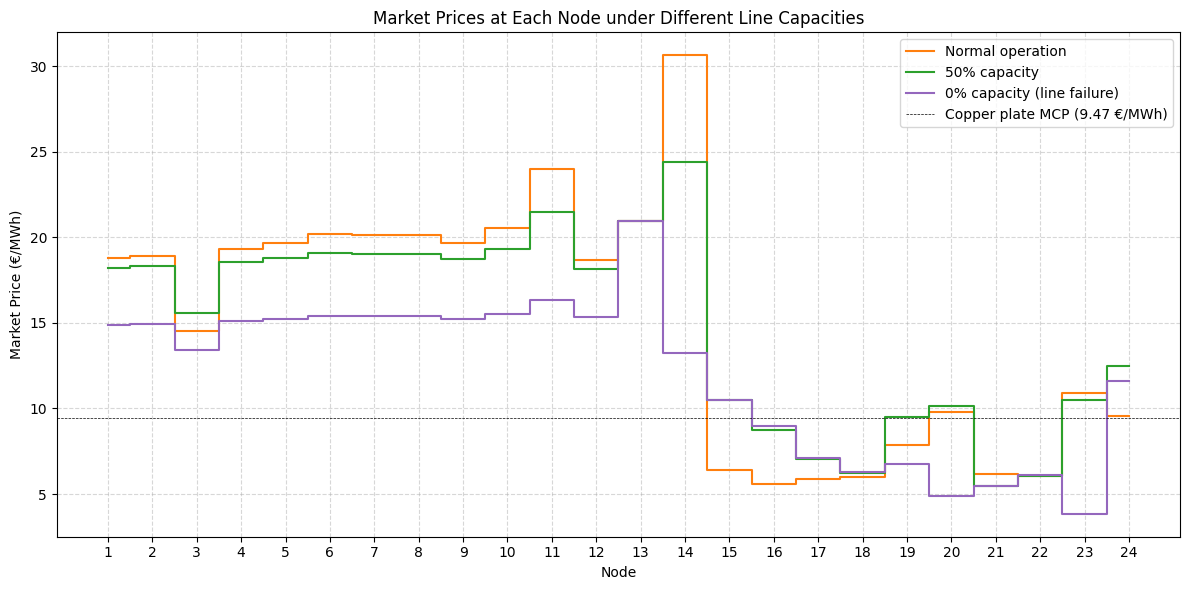

<Figure size 640x480 with 0 Axes>

In [12]:
# plot stepwise marketprices for each node
from Step_3_sensitivity_analysis_data import prices_normal, prices_75percent, prices_50percent, prices_25percent, prices_0percent

plt.figure(figsize=(12, 6))

plt.step(range(1, 25), prices_normal, color='tab:orange', label='Normal operation', where='mid')
#plt.step(range(1, 25), prices_75percent, color='tab:blue', label='75% capacity', where='mid')
plt.step(range(1, 25), prices_50percent, color='tab:green', label='50% capacity', where='mid')
#plt.step(range(1, 25), prices_25percent, color='tab:red', label='25% capacity', where='mid')
plt.step(range(1, 25), prices_0percent, color='tab:purple', label='0% capacity (line failure)', where='mid')

plt.axhline(9.47, color='black', linestyle='--', linewidth=0.5, label = "Copper plate MCP (9.47 €/MWh)")
plt.xlabel('Node')
plt.ylabel('Market Price (€/MWh)')
plt.title('Market Prices at Each Node under Different Line Capacities')
plt.xticks(range(1, 25))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()
plt.savefig(os.path.join(os.environ['PYTHONPATH'], 'Results', 'step3_nodal_sensitivity.png'),
         dpi=150, bbox_inches='tight')

In [13]:
# Dictionary to store flows
line_flows = {}

for v in transmission_lines:
    from_node = transmission_lines[v]['from']
    to_node = transmission_lines[v]['to']
    X = transmission_lines[v]['reactance']

    # DC flow
    P_ij = (voltage_angle_variables[from_node].X - voltage_angle_variables[to_node].X) / X
    line_flows[v] = P_ij

In [14]:
# Dictionary to store flows
line_flows = {}

for v in transmission_lines:
    from_node = transmission_lines[v]['from']
    to_node = transmission_lines[v]['to']
    X = transmission_lines[v]['reactance']

    # DC flow
    P_ij = (voltage_angle_variables[from_node].X - voltage_angle_variables[to_node].X) / X
    line_flows[v] = P_ij

In [15]:
for v in transmission_lines:
    from_node = transmission_lines[v]['from']
    to_node = transmission_lines[v]['to']
    price_diff = Balance_constraints[from_node].Pi - Balance_constraints[to_node].Pi

    print(f"Line {v}: Flow = {line_flows[v]:.2f} MW, Capacity = {transmission_lines[v]['capacity_MVA']} MW, "
          f"Price difference = {price_diff:.2f} $/MWh")

Line L1: Flow = 52.10 MW, Capacity = 175 MW, Price difference = -0.12 $/MWh
Line L2: Flow = -7.64 MW, Capacity = 175 MW, Price difference = 3.86 $/MWh
Line L3: Flow = 6.83 MW, Capacity = 350 MW, Price difference = -0.80 $/MWh
Line L4: Flow = 54.89 MW, Capacity = 175 MW, Price difference = -0.37 $/MWh
Line L5: Flow = 59.09 MW, Capacity = 175 MW, Price difference = -1.15 $/MWh
Line L6: Flow = 65.85 MW, Capacity = 175 MW, Price difference = -4.64 $/MWh
Line L7: Flow = -108.84 MW, Capacity = 400 MW, Price difference = 4.51 $/MWh
Line L8: Flow = -14.02 MW, Capacity = 175 MW, Price difference = -0.30 $/MWh
Line L9: Flow = 83.85 MW, Capacity = 350 MW, Price difference = -0.83 $/MWh
Line L10: Flow = -68.13 MW, Capacity = 175 MW, Price difference = -0.36 $/MWh
Line L11: Flow = 38.81 MW, Capacity = 350 MW, Price difference = 0.00 $/MWh
Line L12: Flow = -65.37 MW, Capacity = 175 MW, Price difference = 0.42 $/MWh
Line L13: Flow = -54.85 MW, Capacity = 175 MW, Price difference = -0.42 $/MWh
Line L1

In [16]:
# check status and print results
# TBD 
if model.status == GRB.OPTIMAL:
    print(f"Optimal objective: {model.ObjVal}")
    print(f"Optimal Dual value of load constraint(Market clearing price): {Balance_constraints[5].Pi:.2f} $/MWh")
    for i in VARIABLES:
        print(f"Optimal dispatch of generator {i}: {variables[i].X:.2f} MW")
    for i in LOAD_VARIABLES:
        print(f"Optimal dispatch of load {i}: {load_variables[i].X:.2f} MW")
else:
    print(f"optimization of {model.ModelName} was not successful")

Optimal objective: 69635.68067571972
Optimal Dual value of load constraint(Market clearing price): 17.60 $/MWh
Optimal dispatch of generator G1: 152.00 MW
Optimal dispatch of generator G2: 152.00 MW
Optimal dispatch of generator G3: 12.89 MW
Optimal dispatch of generator G4: 91.69 MW
Optimal dispatch of generator G5: 0.00 MW
Optimal dispatch of generator G6: 0.00 MW
Optimal dispatch of generator G7: 0.00 MW
Optimal dispatch of generator G8: 54.93 MW
Optimal dispatch of generator G9: 400.00 MW
Optimal dispatch of generator G10: 300.00 MW
Optimal dispatch of generator G11: 310.00 MW
Optimal dispatch of generator G12: 350.00 MW
Optimal dispatch of generator W1: 131.63 MW
Optimal dispatch of generator W2: 143.28 MW
Optimal dispatch of generator W3: 142.54 MW
Optimal dispatch of generator W4: 124.68 MW
Optimal dispatch of generator W5: 144.88 MW
Optimal dispatch of generator W6: 139.97 MW
Optimal dispatch of load Load1: 100.72 MW
Optimal dispatch of load Load2: 90.12 MW
Optimal dispatch of 

In [17]:


# Generator to node mapping is already in your generator data
# Then get the market price (dual) from the balance constraint at that node

for g in VARIABLES:
    node = generators[g]['node']          # node of this generator
    price = Balance_constraints[node].Pi  # dual of the node balance constraint
    profit = (price - objective_coeff[g]) * variables[g].X
    print(f"Profit of generator {g} at node {node}: {profit:.2f} $")

print("Total production surplus: " + str(sum((Balance_constraints[generators[g]['node']].Pi - objective_coeff[g]) * variables[g].X for g in VARIABLES)))


#The social welfare of the system
social_welfare = model.ObjVal
print(f"Social welfare of the system: {social_welfare:.2f} EUR")



Profit of generator G1 at node 1: 792.29 $
Profit of generator G2 at node 2: 810.71 $
Profit of generator G3 at node 7: 0.00 $
Profit of generator G4 at node 13: 0.00 $
Profit of generator G5 at node 15: -0.00 $
Profit of generator G6 at node 15: -0.00 $
Profit of generator G7 at node 16: -0.00 $
Profit of generator G8 at node 18: 0.00 $
Profit of generator G9 at node 21: 237.71 $
Profit of generator G10 at node 22: 1578.22 $
Profit of generator G11 at node 23: 393.93 $
Profit of generator G12 at node 23: 332.76 $
Profit of generator W1 at node 3: 1704.19 $
Profit of generator W2 at node 5: 2522.09 $
Profit of generator W3 at node 7: 2567.21 $
Profit of generator W4 at node 16: 605.06 $
Profit of generator W5 at node 21: 775.75 $
Profit of generator W6 at node 23: 1458.59 $
Total production surplus: 13778.512075991575
Social welfare of the system: 69635.68 EUR
